In [5]:
#import user modules
#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

import sys
my_path = "../../Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

from fit_funcs import *
import costfun.costfun as cost
import utils.figures as fig_help
from RandomMatrixTheory import goe, gue
from Quad_tools import *
import entropy as ent

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)

import itertools
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}

%matplotlib inline
colors_ls = (list(mcolors.TABLEAU_COLORS)[:200])
colors_ls_cyc = itertools.cycle(colors_ls)

markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   


# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import gamma as Gamma
from scipy.special import lambertw
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
 
# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists

DIM = 3
modello = 'Anderson'


def base_dir(model, d, BC = 0):
    """
    Base directory for input model for d-dimension
    """
    dirx = f"../results/{model}/" + (f"" if model == 'PLRB' or model == 'RP' or model == 'SYK2' else  f"dim={d}/") + ( '' if model == 'RP' or model == 'SYK2' else (f"PBC/" if BC else f"OBC/") )
    return dirx

print(base_dir(modello, DIM))

%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}

/Users/rafal.swietek/Projects/CODES/QHamSolver/Quadratic/Jupyter_Python
/Users/rafal.swietek/opt/anaconda3/lib/python39.zip
/Users/rafal.swietek/opt/anaconda3/lib/python3.9
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/lib-dynload

/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/aeosa
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/locket-0.2.1-py3.9.egg
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/IPython/extensions
/Users/rafal.swietek/.ipython
../../Python/
../results/Anderson/dim=3/OBC/


In [106]:

def borels_triangle(n, k):
    return 1 / n * binom(2*n, n-k-1) * binom(n+k-1, k)

def QC_terms(f, n):
    y = 0
    for k in range(n):
        y += (-1)**k * borels_triangle(n, k) ** f**k
    return f**n * y
    # return f**n * np.sum( [(-1)**k * borels_triangle(n, k) ** f**k for k in range(n)] )

def correction(n=4):
    return np.log(2) - np.sum( [1 / (2 * k * (2 * k - 1)) for k in range(1, n)] )

def gdeg(x, n):    
    if n == 1:      return 2/(1+x)
    elif n == 2:    return 4*(5+x) / ( (1+x)*(2+x)*(3+x) )
    elif n == 3:    return 8*(x**2 + 15*x + 74) / ( (1+x)*(2+x)*(3+x)*(4+x)*(5+x) )
    elif n == 4:    return 16*(x**3 + 30*x**2 + 371*x + 2118) / ( (1+x)*(2+x)*(3+x)*(4+x)*(5+x)*(6+x)*(7+x) )
    else:           return (2/(1+x))**n

def leading_QC_terms(f, x, n=4):
    res = QC_terms(f, n=1)/2 * gdeg(x, 1)
    if n >= 2:  res += QC_terms(f, n=2) / 12 * gdeg(x,2)
    if n >= 3:  res += QC_terms(f, n=3) / 30 * gdeg(x,3)
    if n >= 4:  res += QC_terms(f, n=4) / 56 * gdeg(x,4)
    # ..... other terms
    return res

def QC_upper_bound(f, x, n):
    return 1 - leading_QC_terms(f, x, n=n) / (np.log(2))

def QC_lower_bound(f, x, n):
    return 1 - (leading_QC_terms(f=f, x=x, n=n) + QC_terms(f=f, n=n) * correction(n=n+1) * gdeg(x=x, n=n)) / (np.log(2))

def QCQ_trace_series(f, x):
    return 1 + (1-2*f+x)*np.log(1-2*f/(1+x)) / (2*f)

def s_QCQ(f, x):
    return 1 - (QCQ_trace_series(f, x)) / np.log(2)

# def s_QCQ(f, x):
#     y = 0
#     for n in range(3):
#         y += 1 / (n + x)
#     return 1 - y / np.log(2)


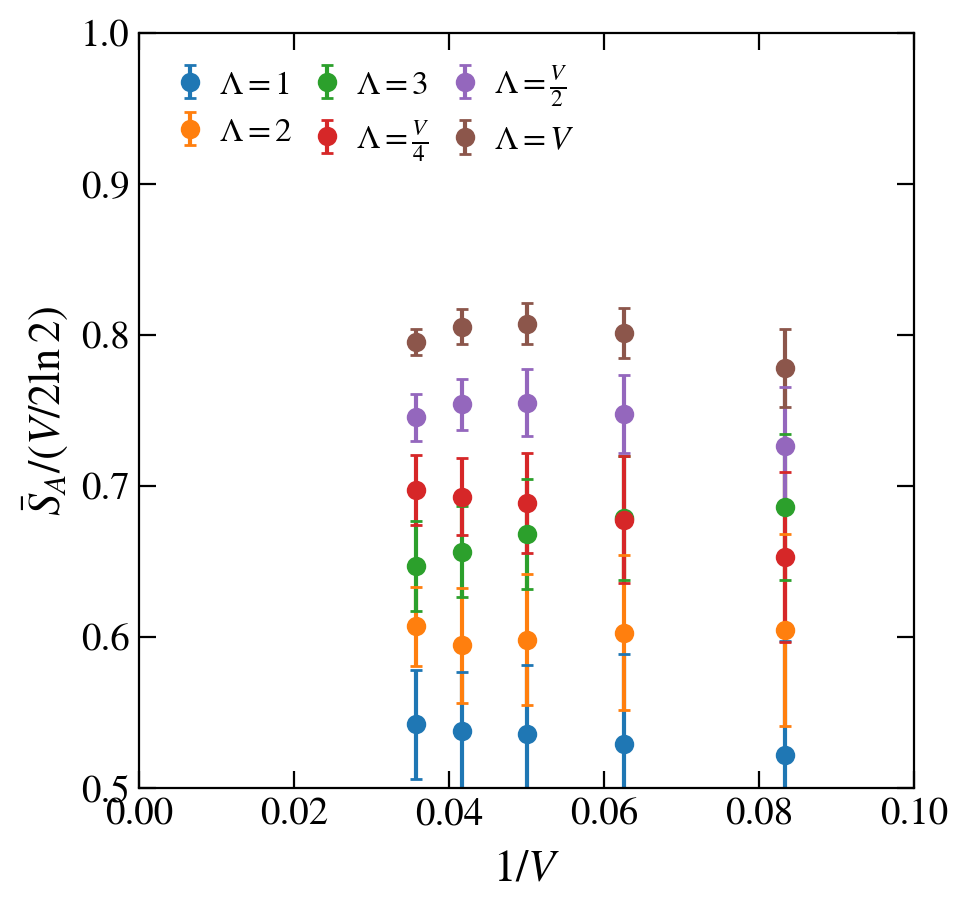

In [128]:
L = 100
w = 1
J = 1
g = 0.618



fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)
# fig, axis_flu

op=1

prefix = base_dir(model='SYK2', d=1) + 'Entropy/Degeneracy/'
if op == 2:   prefix += "AllStates/"
else:         prefix += "RandomChoice/"
# ax_inset = fig_help.add_subplot_axes(axis, fig, [0.5, 0.5, 0.46, 0.46])

colors_ls_cyc = itertools.cycle(colors_ls)
# gams = np.arange(1,201, 1)

# sizes = np.array([100, 200, 500, 1000])

sizes = np.arange(12, 29, 4)

subsize_idx = -1

names = [r"$\Lambda=1$",r"$\Lambda=2$",r"$\Lambda=3$",r"$\Lambda=\frac{V}{4}$", r"$\Lambda=\frac{V}{2}$", r"$\Lambda=V$"]

Gammas = np.array([1, 2, 4, 1/4, 1/2, 1])

colors_ls_cyc = itertools.cycle(colors_ls)

S = []
Svar = []
for id_L, L in enumerate(sizes):
    V = L

    name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
    # print(name)
    if exists(name):
        with h5py.File(name, "r") as file:
            gams = np.array(file.get('Gammas'))
            S.append( np.mean(np.array(file.get('entropy')) / (L//2 * np.log(2)), axis=0) )
            Svar.append( np.mean( (np.array(file.get('entropy')) / (L//2 * np.log(2)))**2 , axis=0))
            # S = np.mean(np.array(file.get('entropy_corr_mat')), axis=0) / (L//2 * np.log(2))
            # axis.plot(gams, S, marker='o', markersize=4, lw=0, color=col, label=r"$L=%d$"%(L))
    else:
        print(name)
        
S = np.transpose( np.array(S) )
Svar = np.transpose( np.array(Svar) )
for ii, nam in enumerate( names ):
    col = next(colors_ls_cyc)
    # axis.scatter(1/sizes, S[ii], marker='o', s=10, color=col, label=r"%s"%(nam))
    axis.errorbar(1/sizes, S[ii],  yerr=np.sqrt(Svar[ii] - S[ii]**2), fmt='o',  color=col, capsize=2, label=r"%s"%(nam))
    # axis.axhline(y = s_QCQ(1/2, gams), ls='--', color='k', label=r'$s_{QCQ}(\Gamma,1/2)$')

# gams = np.linspace(1, max(sizes), 100000)
# axis.plot(gams, s_QCQ(1/2, gams), ls='--', color='k', label=r'$s_{QCQ}(\Gamma,1/2)$')
# axis.plot(gams, s_QCQ(1, gams), ls='--', color='k', label=r'${\rm NG}(\Gamma)$')
# axis.plot(gams, s_QCQ(1/4, gams), ls='--', color='red', label=r'$s_{QCQ}(\Gamma,1/4)$')
# axis.plot(gams, s_QCQ(1/6, gams), ls='--', color='blue', label=r'$s_{QCQ}(\Gamma,1/6)$')
# print(s_QCQ(1, 1.01))
# axis.annotate(r"$f=\frac{1}{2}$", xy=(1.3, 0.55), fontsize=14, rotation=0)
# axis.annotate(r"$f=\frac{1}{4}$", xy=(1.3, 0.8), fontsize=14, rotation=0)
# axis.annotate(r"$f=\frac{1}{6}$", xy=(1.3, 0.93), fontsize=14, rotation=0)

fig_help.set_plot_elements(axis, ylabel=r"${\bar{S}_A} / (V/2\ln2)$", xlabel=r"$1/V$", font_size=14, set_legend=True, xlim=(0, 0.1), ylim=(0.5, 1.0), xscale='linear', yscale='linear')
axis.legend(loc = 'upper left', ncol=3, columnspacing=0.4, frameon=False, fontsize=12, handletextpad=0.25, handlelength = 1.25)


# fig_help.set_plot_elements(ax_inset, ylabel=r"${\bar{S}_A} / \ln2$", xlabel=r"$W$", font_size=14, set_legend=False, xlim=(8.0, 25.0), ylim=(0.7, 1.0))

fig.subplots_adjust(wspace = 0.3, hspace=0.05)


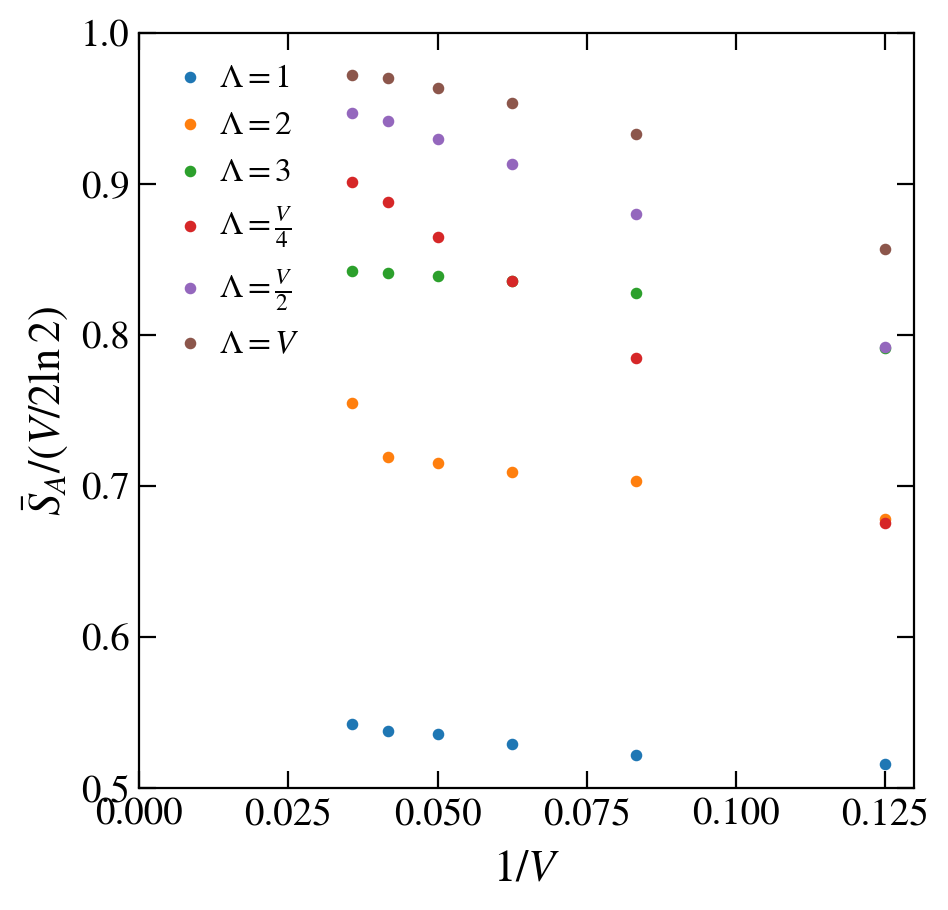

In [ ]:
L = 100
w = 1
J = 1
g = 0.618



fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)
# fig, axis_flu

op=1

prefix = base_dir(model='SYK2', d=1) + 'Entropy/Degeneracy/'
if op == 2:   prefix += "AllStates/"
else:         prefix += "RandomChoice/"
# ax_inset = fig_help.add_subplot_axes(axis, fig, [0.5, 0.5, 0.46, 0.46])

colors_ls_cyc = itertools.cycle(colors_ls)
# gams = np.arange(1,201, 1)

# sizes = np.array([100, 200, 500, 1000])

sizes = np.arange(8, 29, 4)

subsize_idx = -1

names = [r"$\Lambda=1$",r"$\Lambda=2$",r"$\Lambda=3$",r"$\Lambda=\frac{V}{4}$", r"$\Lambda=\frac{V}{2}$", r"$\Lambda=V$"]

Gammas = np.array([1, 2, 4, 1/4, 1/2, 1])

colors_ls_cyc = itertools.cycle(colors_ls)

S = []
for id_L, L in enumerate(sizes):
    V = L

    name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
    # print(name)
    if exists(name):
        with h5py.File(name, "r") as file:
            gams = np.array(file.get('Gammas'))
            S.append( np.array(file.get('entropy_corr_mat'))[L//2-1] / (L//2 * np.log(2)) )
            # S = np.mean(np.array(file.get('entropy_corr_mat')), axis=0) / (L//2 * np.log(2))
            # axis.plot(gams, S, marker='o', markersize=4, lw=0, color=col, label=r"$L=%d$"%(L))
    else:
        print(name)
        
S = np.transpose( np.array(S) )
for ii, nam in enumerate( names ):
    col = next(colors_ls_cyc)
    axis.scatter(1/sizes, S[ii], marker='o', s=10, color=col, label=r"%s"%(nam))
    # axis.axhline(y = s_QCQ(1/2, gams), ls='--', color='k', label=r'$s_{QCQ}(\Gamma,1/2)$')

# gams = np.linspace(1, max(sizes), 100000)
# axis.plot(gams, s_QCQ(1/2, gams), ls='--', color='k', label=r'$s_{QCQ}(\Gamma,1/2)$')
# axis.plot(gams, s_QCQ(1, gams), ls='--', color='k', label=r'${\rm NG}(\Gamma)$')
# axis.plot(gams, s_QCQ(1/4, gams), ls='--', color='red', label=r'$s_{QCQ}(\Gamma,1/4)$')
# axis.plot(gams, s_QCQ(1/6, gams), ls='--', color='blue', label=r'$s_{QCQ}(\Gamma,1/6)$')
# print(s_QCQ(1, 1.01))
# axis.annotate(r"$f=\frac{1}{2}$", xy=(1.3, 0.55), fontsize=14, rotation=0)
# axis.annotate(r"$f=\frac{1}{4}$", xy=(1.3, 0.8), fontsize=14, rotation=0)
# axis.annotate(r"$f=\frac{1}{6}$", xy=(1.3, 0.93), fontsize=14, rotation=0)

fig_help.set_plot_elements(axis, ylabel=r"${\bar{S}^{corr}_A} / (V/2\ln2)$", xlabel=r"$1/V$", font_size=14, set_legend=True, xlim=(0, 0.13), ylim=(0.5, 1.0), xscale='linear', yscale='linear')
axis.legend(loc = 'upper left', ncol=1, columnspacing=0.4, frameon=False, fontsize=12, handletextpad=0.25, handlelength = 1.25)


# fig_help.set_plot_elements(ax_inset, ylabel=r"${\bar{S}_A} / \ln2$", xlabel=r"$W$", font_size=14, set_legend=False, xlim=(8.0, 25.0), ylim=(0.7, 1.0))

fig.subplots_adjust(wspace = 0.3, hspace=0.05)


No handles with labels found to put in legend.


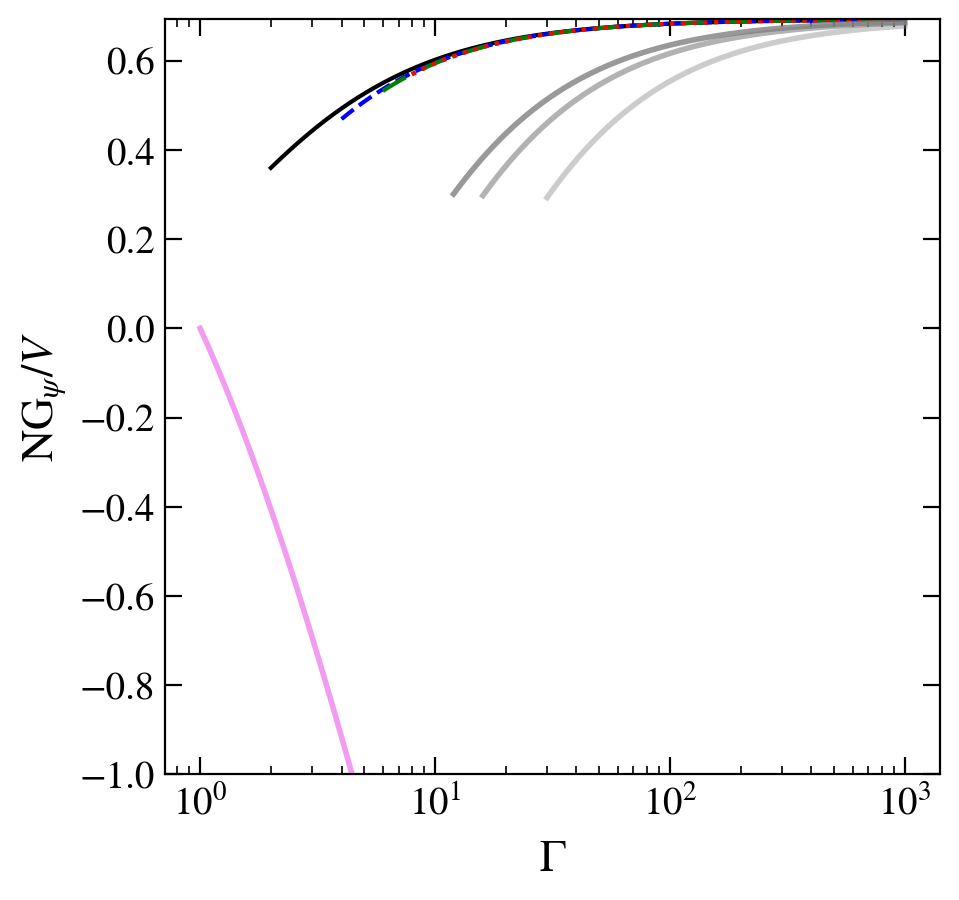

In [64]:
def res(x, n):
    return Gamma(x+1) * Gamma(2*n+1) / Gamma(2*n+x)

# def Z2(x): return res(x,1)
# def Z4(x): return 3 * res(x,1)**2 - 2 * res(x,2)
# def Z6(x): return 15 * res(x,1)**3 - 30 * res(x,1)*res(x,2) + 15 * res(x,3)
# def Z8(x): return 105 * res(x,1)**4 - 420 * res(x,1)**2 * res(x,2) + 140 * res(x,2)**2 + 448*res(x,1)*res(x,3) - 272*res(x,4)

def Z2(x): return 2 / (1+x)
def Z4(x): return 12 / ( (2+x)*(3+x) )
def Z6(x): return 120 / ( (3+x)*(4+x)*(5+x) )
def Z8(x): return 1680 / ( (4+x)*(5+x)*(6+x)*(7+x) )

x = np.linspace(1, 100, 100000)

fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)

x = np.linspace(2, 1000, 100000)
axis.plot(x, np.log(2) - Z2(x) / 2, ls='-', color='k')
x = np.linspace(4, 1000, 100000)
axis.plot(x, np.log(2) - Z2(x) / 2 - Z4(x) / 12, ls='--', color='blue')
x = np.linspace(6, 1000, 100000)
axis.plot(x, np.log(2) - Z2(x) / 2 - Z4(x) / 12 - Z6(x) / 30, ls='-.', color='green')
x = np.linspace(8, 1000, 100000)
axis.plot(x, np.log(2) - Z2(x) / 2 - Z4(x) / 12 - Z6(x) / 30 - Z8(x) / 56, ls=':', color='red')
x = np.linspace(12, 1000, 100000)
axis.plot(x, np.log(2) - (1/(1+x) + 1/(2+x) + 1/(3+x) + 1/(4+x) + 1/(5+x) + 1/(6+x)), ls='-', lw=2, color='gray', alpha=0.8)
x = np.linspace(16, 1000, 100000)
axis.plot(x, np.log(2) - (1/(1+x) + 1/(2+x) + 1/(3+x) + 1/(4+x) + 1/(5+x) + 1/(6+x) + 1/(7+x) + 1/(8+x)), ls='-', lw=2, color='gray', alpha=0.6)
x = np.linspace(30, 1000, 100000)
axis.plot(x, np.log(2) - (1/(1+x) + 1/(2+x) + 1/(3+x) + 1/(4+x) + 1/(5+x) + 1/(6+x) + 1/(7+x) + 1/(8+x) + 1/(9+x) + 1/(10+x) + 1/(11+x) + 1/(12+x) + 1/(13+x) + 1/(14+x) + 1/(15+x)), ls='-', lw=2, color='gray', alpha=0.4)

x = np.linspace(1, 1000, 100000)
axis.plot(x, np.log(2 / (1+x)), ls='-', lw=2, color='violet', alpha=0.8)

fig_help.set_plot_elements(axis, ylabel=r"${\rm NG}_\psi/V}$", xlabel=r"$\Gamma$", font_size=14, set_legend=True, ylim=(-1, np.log(2)), xscale='log', yscale='linear')

../results/SYK2/Entropy/Degeneracy/RandomChoice/_L=32,J=1.hdf5
-0.40443978243306855


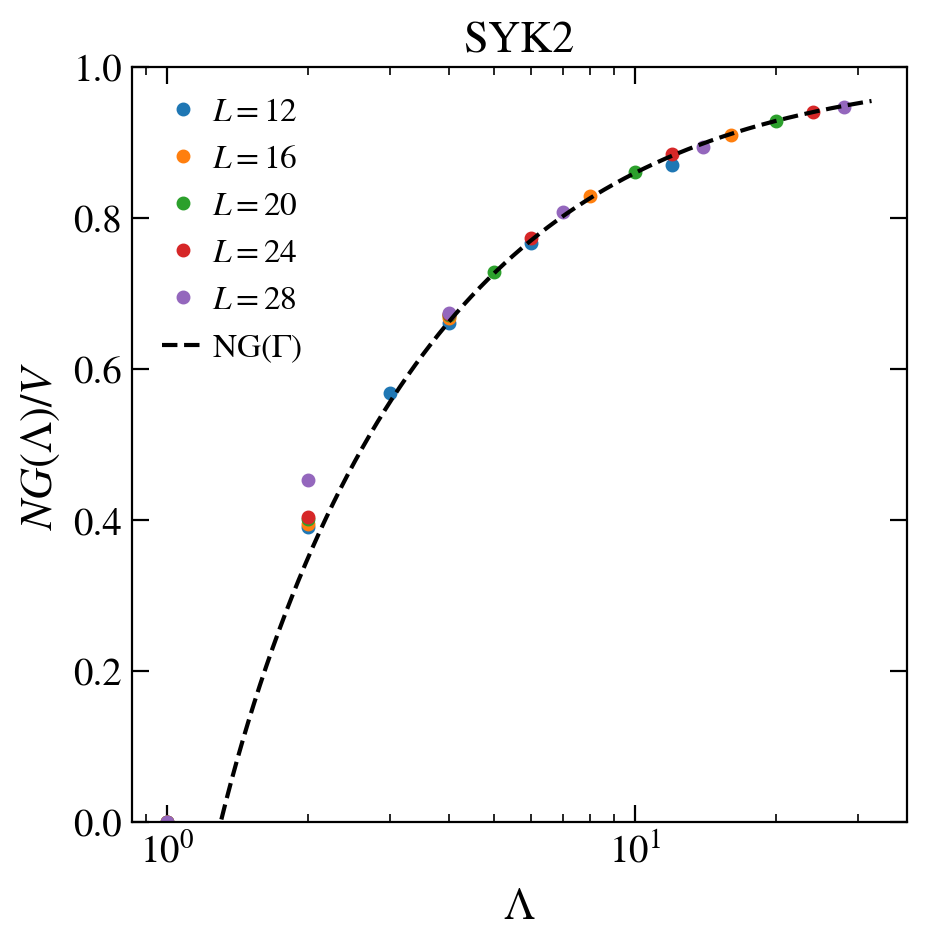

In [118]:
L = 100
w = 1
J = 1
g = 0.618



fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)
# fig, axis_flu

op=1

prefix = base_dir(model='SYK2', d=1) + 'Entropy/Degeneracy/'
if op == 2:   prefix += "AllStates/"
else:         prefix += "RandomChoice/"
# ax_inset = fig_help.add_subplot_axes(axis, fig, [0.5, 0.5, 0.46, 0.46])

colors_ls_cyc = itertools.cycle(colors_ls)
# gams = np.arange(1,201, 1)

# sizes = np.array([100, 200, 500, 1000])

sizes = np.arange(12, 33, 4)

subsize_idx = -1

names = [r"$f=\frac{1}{6}$", r"$f=\frac{1}{4}$", r"$f=\frac{1}{2}$", r"$f=\frac{1}{2}$"]
fracs = [1/6, 1/4, 1/2, 1/2]

colors_ls_cyc = itertools.cycle(colors_ls)
for id_L, L in enumerate(sizes):
    V = L
    LA = fracs[subsize_idx] * L
    col = next(colors_ls_cyc)

    name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
    # print(name)
    if exists(name):
        with h5py.File(name, "r") as file:
            gams = np.array(file.get('Gammas'))
            S = np.mean(np.array(file.get('Non-Gaussianity')), axis=0) / (L * np.log(2))
            # S = np.mean(np.array(file.get('entropy_corr_mat')), axis=0) / (L//2 * np.log(2))
            axis.plot(gams, S, marker='o', markersize=4, lw=0, color=col, label=r"$L=%d$"%(L))
    else:
        print(name)
    # ax_inset.plot(4 * w_vals, ydata, marker='o', markersize=4, label=r"$L=%d$"%(L))
    # axis.axhline(y = 1 - 1. / (V*np.log(2)), color=col, ls='--')


gams = np.linspace(1, max(sizes), 100000)
# axis.plot(gams, s_QCQ(1/2, gams), ls='--', color='k', label=r'$s_{QCQ}(\Gamma,1/2)$')
axis.plot(gams, s_QCQ(1, gams), ls='--', color='k', label=r'${\rm NG}(\Gamma)$')
# axis.plot(gams, s_QCQ(1/4, gams), ls='--', color='red', label=r'$s_{QCQ}(\Gamma,1/4)$')
# axis.plot(gams, s_QCQ(1/6, gams), ls='--', color='blue', label=r'$s_{QCQ}(\Gamma,1/6)$')
print(s_QCQ(1, 1.01))
# axis.annotate(r"$f=\frac{1}{2}$", xy=(1.3, 0.55), fontsize=14, rotation=0)
# axis.annotate(r"$f=\frac{1}{4}$", xy=(1.3, 0.8), fontsize=14, rotation=0)
# axis.annotate(r"$f=\frac{1}{6}$", xy=(1.3, 0.93), fontsize=14, rotation=0)

fig_help.set_plot_elements(axis, ylabel=r"$NG(\Lambda) / V$", xlabel=r"$\Lambda$", font_size=14, set_legend=True, ylim=(0, 1.0), xscale='log', yscale='linear')
axis.legend(loc = 'upper left', columnspacing=0.4, frameon=False, fontsize=12, handletextpad=0.25, handlelength = 1.25)


axis.set_title(r"SYK$2$", fontsize=16)
# fig_help.set_plot_elements(ax_inset, ylabel=r"${\bar{S}_A} / \ln2$", xlabel=r"$W$", font_size=14, set_legend=False, xlim=(8.0, 25.0), ylim=(0.7, 1.0))

fig.subplots_adjust(wspace = 0.3, hspace=0.05)


../results/SYK2/Entropy/Degeneracy/RandomChoice/_L=32,J=1.hdf5
../results/SYK2/Entropy/Degeneracy/RandomChoice/_L=32,J=1.hdf5


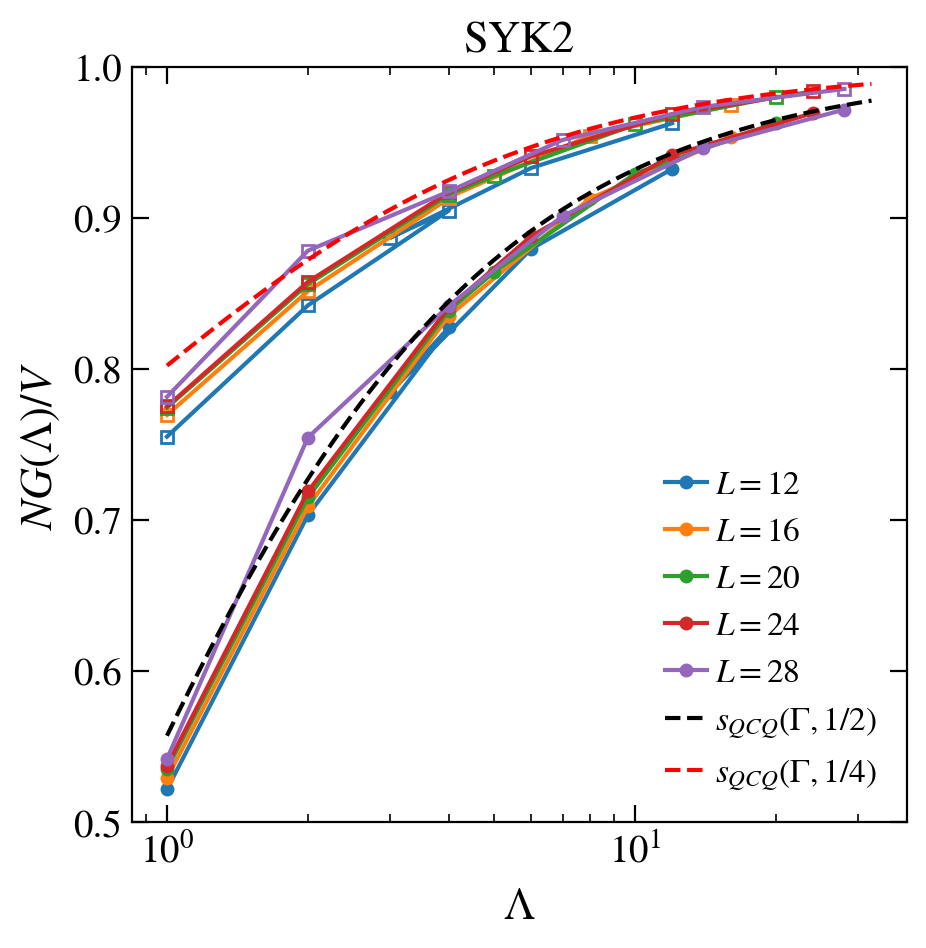

In [122]:
L = 100
w = 1
J = 1
g = 0.618



fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)
# fig, axis_flu

op=1

prefix = base_dir(model='SYK2', d=1) + 'Entropy/Degeneracy/'
if op == 2:   prefix += "AllStates/"
else:         prefix += "RandomChoice/"
# ax_inset = fig_help.add_subplot_axes(axis, fig, [0.5, 0.5, 0.46, 0.46])

colors_ls_cyc = itertools.cycle(colors_ls)
# gams = np.arange(1,201, 1)

# sizes = np.array([100, 200, 500, 1000])

sizes = np.arange(12, 33, 4)

subsize_idx = -1

names = [r"$f=\frac{1}{6}$", r"$f=\frac{1}{4}$", r"$f=\frac{1}{2}$", r"$f=\frac{1}{2}$"]
fracs = [1/4, 1/3, 1/2]

for subsize_idx in [0, 2]:
    colors_ls_cyc = itertools.cycle(colors_ls)
    for id_L, L in enumerate(sizes):
        V = L
        LA = int( fracs[subsize_idx] * L )
        col = next(colors_ls_cyc)

        name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
        # print(name)
        if exists(name):
            with h5py.File(name, "r") as file:
                gams = np.array(file.get('Gammas'))
                S = np.array(file.get('entropy_corr_mat'))
                S = S[LA-1] / (LA * np.log(2))
                if subsize_idx == 2:    axis.plot(gams, S, marker='o', markersize=4, color=col, label=r"$L=%d$"%(L))
                else:                   axis.plot(gams, S, marker='s', markersize=4, color=col, markerfacecolor='None')
        else:
            print(name)
        # ax_inset.plot(4 * w_vals, ydata, marker='o', markersize=4, label=r"$L=%d$"%(L))
        # axis.axhline(y = 1 - 1. / (V*np.log(2)), color=col, ls='--')


gams = np.linspace(1, max(sizes), 1000)
# axis.plot(gams, QC_lower_bound(f=1/2, x=gams, n=1), ls='-', color='gray')
axis.plot(gams, s_QCQ(1/2, gams), ls='--', color='k', label=r'$s_{QCQ}(\Gamma,1/2)$')
# axis.plot(gams, QC_lower_bound(f=1/4, x=gams, n=1), ls='-', color='gray')
axis.plot(gams, s_QCQ(1/4, gams), ls='--', color='red', label=r'$s_{QCQ}(\Gamma,1/4)$')
# axis.plot(gams, s_QCQ(1/6, gams), ls='--', color='blue', label=r'$s_{QCQ}(\Gamma,1/6)$')

fig_help.set_plot_elements(axis, ylabel=r"$NG(\Lambda) / V$", xlabel=r"$\Lambda$", font_size=14, set_legend=True, ylim=(0.5, 1.0), xscale='log', yscale='linear')
axis.legend(loc = 'lower right', columnspacing=0.4, frameon=False, fontsize=12, handletextpad=0.25, handlelength = 1.25)


axis.set_title(r"SYK$2$", fontsize=16)
# fig_help.set_plot_elements(ax_inset, ylabel=r"${\bar{S}_A} / \ln2$", xlabel=r"$W$", font_size=14, set_legend=False, xlim=(8.0, 25.0), ylim=(0.7, 1.0))

fig.subplots_adjust(wspace = 0.3, hspace=0.05)


[[0.07868656 0.08008288 0.08141208 0.08196997 0.08264747 0.08295867]
 [0.15185754 0.15710512 0.16097422 0.16272097 0.16447116 0.16547775]
 [0.21942189 0.23022338 0.23849233 0.24188822 0.24551953 0.2476557 ]
 [0.2814954  0.30007781 0.31389699 0.31970006 0.32599718 0.32943654]
 [0.3379068  0.36625824 0.38721072 0.39588008 0.40558665 0.41092867]
 [0.38768272 0.42894508 0.45855647 0.47052439 0.48449157 0.49197834]
 [0.43256493 0.4875524  0.52788795 0.54396633 0.56261093 0.57264724]
 [0.46869831 0.54228222 0.59530293 0.61588506 0.63992878 0.65294428]
 [0.49762237 0.59301203 0.66026236 0.68638454 0.71640869 0.73267507]
 [0.51923406 0.63934533 0.7228115  0.75503031 0.79225114 0.81202936]
 [0.53238928 0.6818562  0.78308239 0.8222793  0.86751208 0.89104724]
 [0.53747798 0.71908244 0.84091534 0.88813008 0.94174838 0.96969747]
 [0.53371578 0.75219014 0.89600098 0.9520765  1.01522578 1.04790047]
 [0.52021159 0.78013795 0.94916257 1.01464873 1.08802581 1.12577914]
 [0.498643   0.80378732 1.00044755

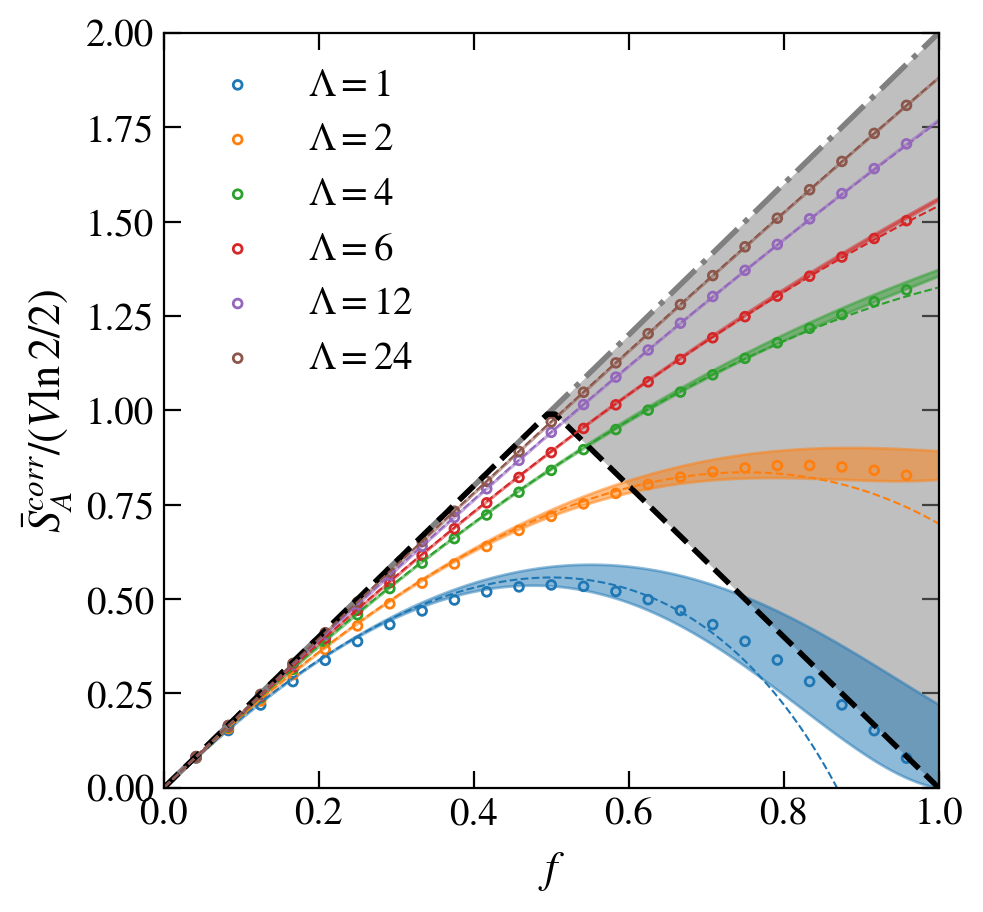

In [116]:
fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,5), dpi = 200)

ff = np.linspace(0, 1.0, 100)
axis.plot(ff, 2*ff, ls='-.', color='gray', lw=2)
axis.plot(ff, 1 - 2*np.abs(0.5 - ff), ls='--', color='k', lw=2)
axis.fill_between(ff, 1 - 2*np.abs(0.5 - ff), 2*ff, color='gray', alpha=0.5, lw=0)

# ff = np.linspace(0., 0.5, 100)
# axis.plot(ff, 2 * ff * (1 - (1 + (1-ff)/ff * np.log(1-ff) ) / np.log(2)), ls=':', color='black')
# ff = np.linspace(.5, 1., 100)
# axis.plot(ff, 2 * (1-ff) * (1 - (1 + ff/(1-ff) * np.log(ff) ) / np.log(2)), ls=':', color='black')    

colors_ls_cyc = itertools.cycle(colors_ls)
L = 100
w = 1
J = 1
g = 0.618


L=24
V=L
op=0
prefix = base_dir(model='SYK2', d=1) + 'Entropy/Degeneracy/'
if op == 2:   prefix += "AllStates/"
else:         prefix += "RandomChoice/"
    
name = prefix + info(L=L, J=J, w=w, g=g, model='SYK2', ext='.hdf5')
# print(name)
if exists(name):
    with h5py.File(name, "r") as file:
        S = np.array(file.get('entropy_corr_mat')) / (V//2*np.log(2))
        # print(S)
subsizes = np.linspace(1, L-1, L-1)

print(S)

Gammas = np.array([1, 2, 4, V//4, V//2, V])
names = [r"$\Lambda=1$",r"$\Lambda=2$",r"$\Lambda=3$",r"$\Lambda=\frac{V}{4}$", r"$\Lambda=\frac{V}{2}$", r"$\Lambda=V$"]
for iig in range(Gammas.size):
    gam = Gammas[iig]
    col = next(colors_ls_cyc)

    ff = np.linspace(0, 1, 1000)
    axis.plot(ff, 2 * ff * s_QCQ(ff, gam), ls='--', color=col, lw=0.75)
    axis.fill_between(ff, 2*ff*QC_lower_bound(f=ff, x=gam, n=3), 2*ff*QC_upper_bound(f=ff, x=gam, n=3), alpha=0.5, color=col)
    
    # print(2 * ff * ( 1 - (s_QCQ(ff, gam)) / (np.log(2)) ))
    
    # ff = np.linspace(0.5, 1.0, 100)
    # axis.plot(ff, 2*(1-ff)*s_QCQ(1-ff, gam), ls='-', color=col, lw=0.75)

    axis.scatter(subsizes / L, S[:, iig], color=col, s=10, facecolor='None', label=r"$\Lambda=%d$"%gam)
    # axis.scatter(1 - subsizes[::5] / L, S[::5,gam - 1], color=col, s=10, facecolor='None')
    # axis.axvline(x=np.sqrt(gam), ls=':', color=col)
    
fig_help.set_plot_elements(axis, ylabel=r"${\bar{S}^{corr}_A} / (V\ln2/2)$", xlabel=r"$f$", font_size=14, set_legend=True, xlim=(0,1), ylim=(0,2), xscale='linear', yscale='linear')
